In [3]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Dataset AmesHousing.csv

## 1. Problem Statement
The objective of this project is to build a machine learning model to predict house sale prices (`SalePrice`) using the Ames Housing dataset. The dataset contains both numerical and categorical features with missing values, which need to be properly handled before training the model.

## 2. Approach
1. Performed Exploratory Data Analysis (EDA) to understand data distribution and missing values.  
2. Dropped non-informative columns such as IDs and highly sparse features.  
3. Handled missing values using:
   - Median imputation for numerical features.
   - Mode or "None" imputation for categorical features.  
4. Verified preprocessing using missing value checks and visualizations.  
5. Split the data into training and testing sets


In [4]:
data=pd.read_csv("/content/drive/MyDrive/colab_data/AmesHousing.csv")
data.shape

(2930, 82)

In [5]:
data.sample(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
422,423,528104070,60,RL,104.0,13518,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,7,2009,New,Partial,485000
1301,1302,902202090,50,RM,75.0,9000,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,140000
567,568,533210020,160,FV,30.0,3000,Pave,Pave,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2009,New,Partial,173733
2584,2585,535304020,20,RL,66.0,12778,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,1,2006,WD,Normal,139500
1352,1353,903401020,50,RL,60.0,9120,Pave,Pave,Reg,Lvl,...,0,NaN,GdPrv,NaN,0,6,2008,WD,Normal,184000
2548,2549,534427090,190,RL,75.0,10382,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,3,2006,ConLD,Normal,140000
2174,2175,908152060,80,RL,65.0,6285,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2007,WD,Normal,133500
2783,2784,907201230,80,RL,42.0,10385,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,174000
2080,2081,905475270,20,RL,60.0,5400,Pave,NaN,Reg,HLS,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,118000
224,225,905106170,20,RL,65.0,7832,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,137250


In [6]:
(data.isnull().sum()/len(data))*100
pd.set_option("display.max_rows",None)

In [7]:
(data.isnull().sum()/len(data))*100

,0
Order,0.000000
PID,0.000000
MS SubClass,0.000000
MS Zoning,0.000000
Lot Frontage,16.723549
Lot Area,0.000000
Street,0.000000
Alley,93.242321
Lot Shape,0.000000
Land Contour,0.000000


In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
corr = data.corr(numeric_only=True)['SalePrice'].sort_values()
corr.head(10)

,SalePrice
PID,-0.246521
Enclosed Porch,-0.128787
Kitchen AbvGr,-0.119814
Overall Cond,-0.101697
MS SubClass,-0.085092
Low Qual Fin SF,-0.037660
Bsmt Half Bath,-0.035835
Order,-0.031408
Yr Sold,-0.030569
Misc Val,-0.015691


In [10]:
data=data.drop([ 'Order', 'PID','Pool QC', 'Misc Feature','Alley', 'Fence','Misc Val','BsmtFin SF 2'],axis=1)

In [11]:
data.shape

(2930, 74)

In [12]:
num_col=data.select_dtypes(include=["int64","float64"]).columns
cat_col=data.select_dtypes(include=["object"]).columns
print("Numerical columns:\n", num_col,    num_col.shape)
print("\nCategorical columns:\n", cat_col,   cat_col.shape)


Numerical columns:
 Index(['MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area',
       'BsmtFin SF 1', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt',
       'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF',
       'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Mo Sold',
       'Yr Sold', 'SalePrice'],
      dtype='object') (35,)

Categorical columns:
 Index(['MS Zoning', 'Street', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual

In [13]:
X=data.drop("SalePrice",axis=1)
y=data["SalePrice"]

# TRAIN TEST SPLIT(80/20)

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

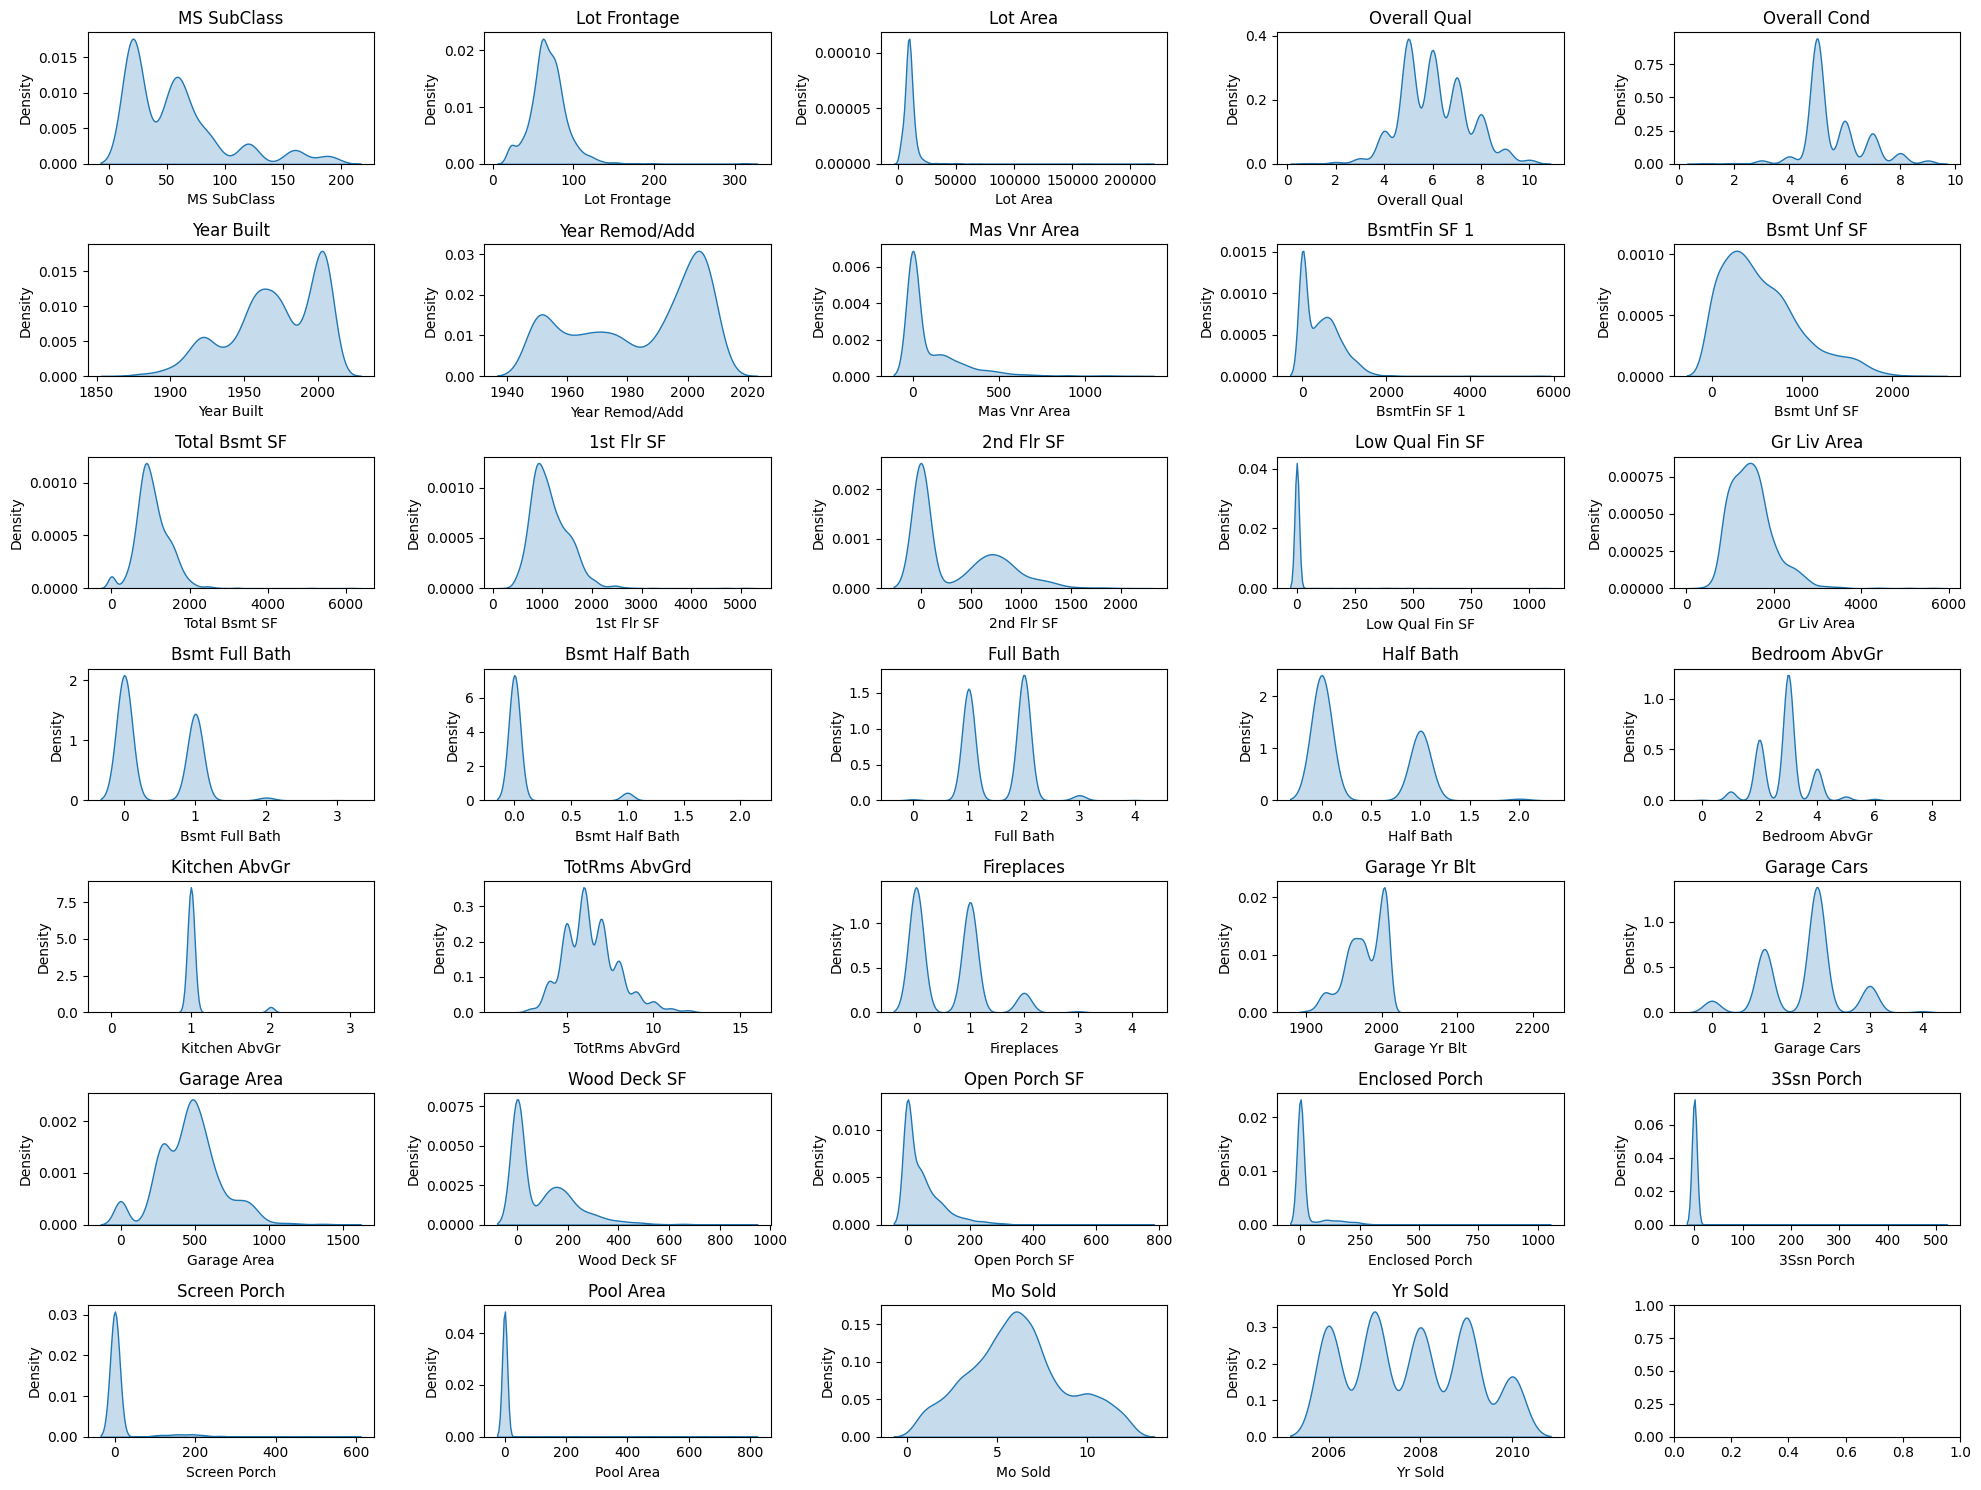

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
num_cols=['MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area',
       'BsmtFin SF 1', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt',
       'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF',
       'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Mo Sold',
       'Yr Sold']
import math
n_cols=5
n_rows=math.ceil(len(num_cols)/n_cols)
fig, axes=plt.subplots(n_rows, n_cols, figsize=(20, 15))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.kdeplot(X_train[col], ax=axes[i], fill=True)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


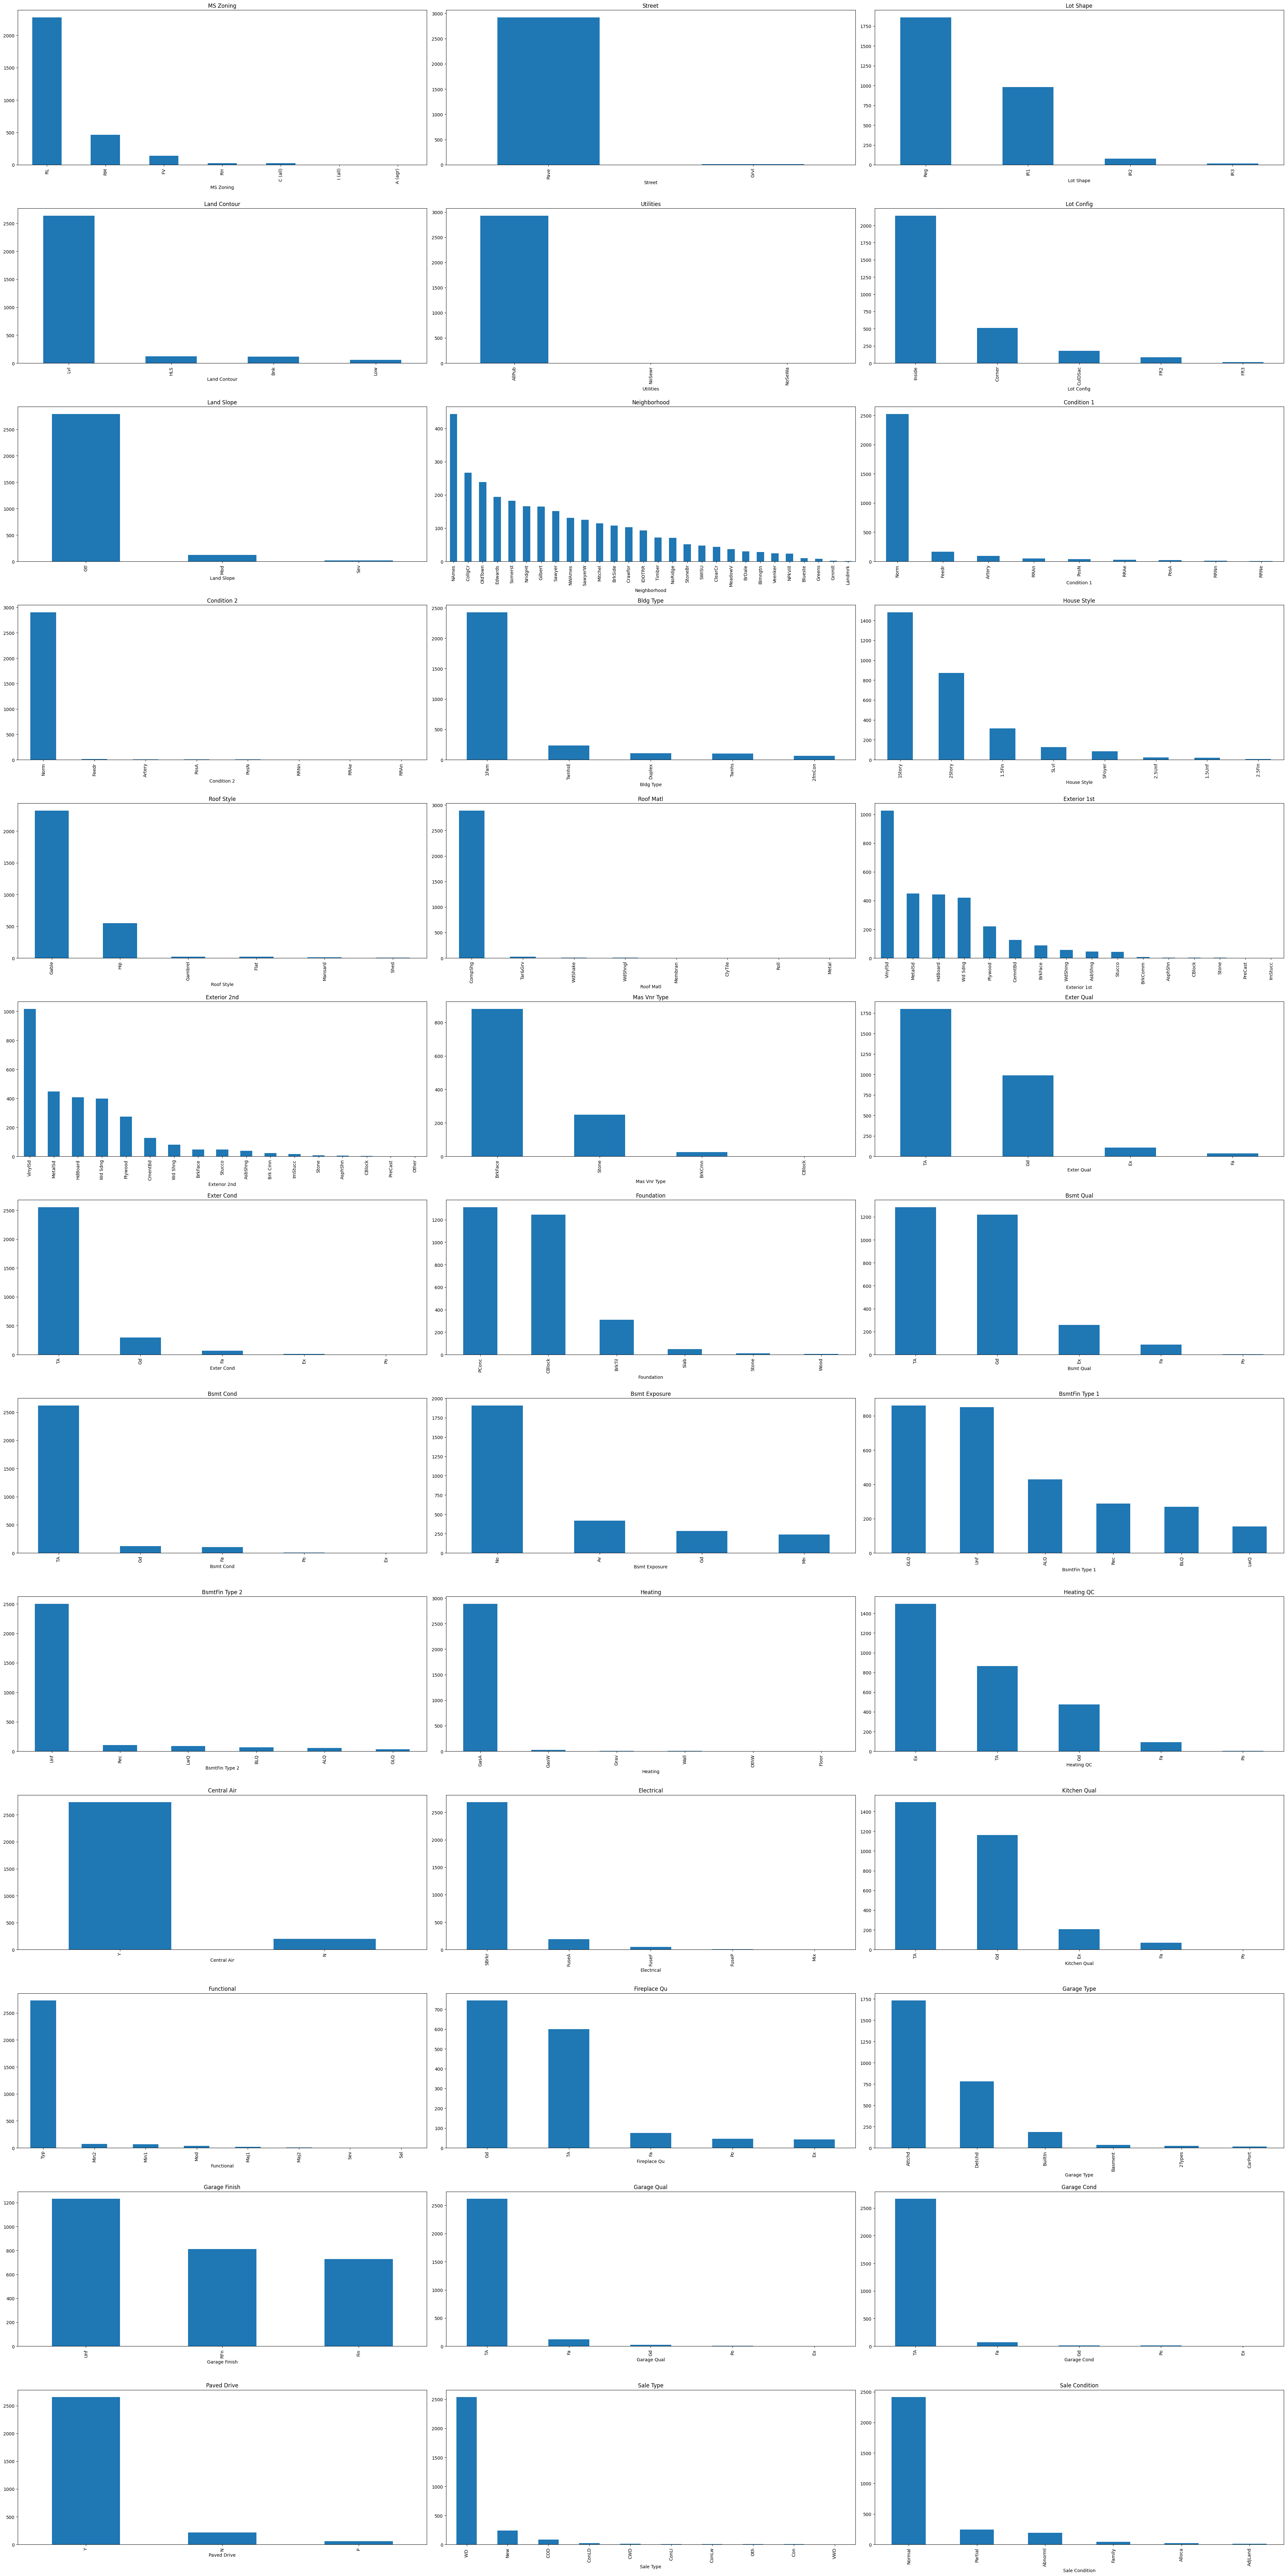

In [26]:
cat_cols=['MS Zoning', 'Street', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Sale Type', 'Sale Condition']
n_cols = 3
n_rows = math.ceil(len(cat_cols)/n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(40, 80))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    data[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()


# APPLYING MEDIAN(NUMERICAL COLUMNS) AND MODE(CATEGORICAL COLUMNS)

In [32]:
from sklearn.impute import SimpleImputer
num_median=SimpleImputer(strategy="median")
cat_mode=SimpleImputer(strategy="most_frequent")
X_train_num_median=X_train.copy()
X_test_num_median=X_test.copy()
X_train_cat_mode=X_train.copy()
X_test_cat_mode=X_test.copy()
# Median
X_train_num_median[num_cols]=num_median.fit_transform(X_train[num_cols])
X_test_num_median[num_cols]=num_median.transform(X_test[num_cols])
#Mode
X_train_cat_mode[cat_cols] = cat_mode.fit_transform(X_train[cat_cols])
X_test_cat_mode[cat_cols]  = cat_mode.transform(X_test[cat_cols])

In [36]:
X_train_cat_mode[cat_cols].isnull().sum()/len(data)*100

,0
MS Zoning,0.0
Street,0.0
Lot Shape,0.0
Land Contour,0.0
Utilities,0.0
Lot Config,0.0
Land Slope,0.0
Neighborhood,0.0
Condition 1,0.0
Condition 2,0.0


In [37]:
X_test_cat_mode[cat_cols].isnull().sum()/len(data)*100

,0
MS Zoning,0.0
Street,0.0
Lot Shape,0.0
Land Contour,0.0
Utilities,0.0
Lot Config,0.0
Land Slope,0.0
Neighborhood,0.0
Condition 1,0.0
Condition 2,0.0


In [38]:
X_train_num_median[num_cols].isnull().sum()/len(data)*100

,0
MS SubClass,0.0
Lot Frontage,0.0
Lot Area,0.0
Overall Qual,0.0
Overall Cond,0.0
Year Built,0.0
Year Remod/Add,0.0
Mas Vnr Area,0.0
BsmtFin SF 1,0.0
Bsmt Unf SF,0.0


In [39]:
X_test_num_median[num_cols].isnull().sum()/len(data)*100

,0
MS SubClass,0.0
Lot Frontage,0.0
Lot Area,0.0
Overall Qual,0.0
Overall Cond,0.0
Year Built,0.0
Year Remod/Add,0.0
Mas Vnr Area,0.0
BsmtFin SF 1,0.0
Bsmt Unf SF,0.0


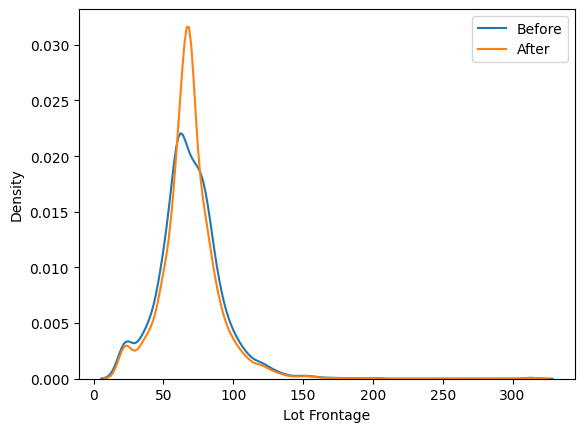

In [40]:
sns.kdeplot(X_train['Lot Frontage'], label='Before')
sns.kdeplot(X_train_num_median['Lot Frontage'], label='After')
plt.legend()
plt.show()


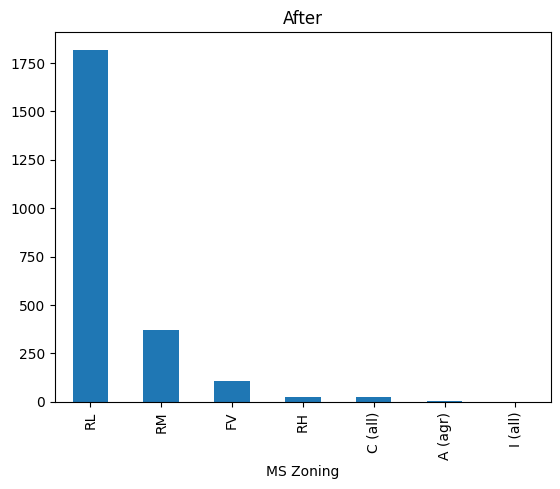

In [42]:
X_train['MS Zoning'].value_counts().plot(kind='bar', title='Before')
X_train_cat_mode['MS Zoning'].value_counts().plot(kind='bar', title='After')
plt.show()


# BEFORE & AFTER APPLYING MEDIAN ON NUMERICAL COLUMNS

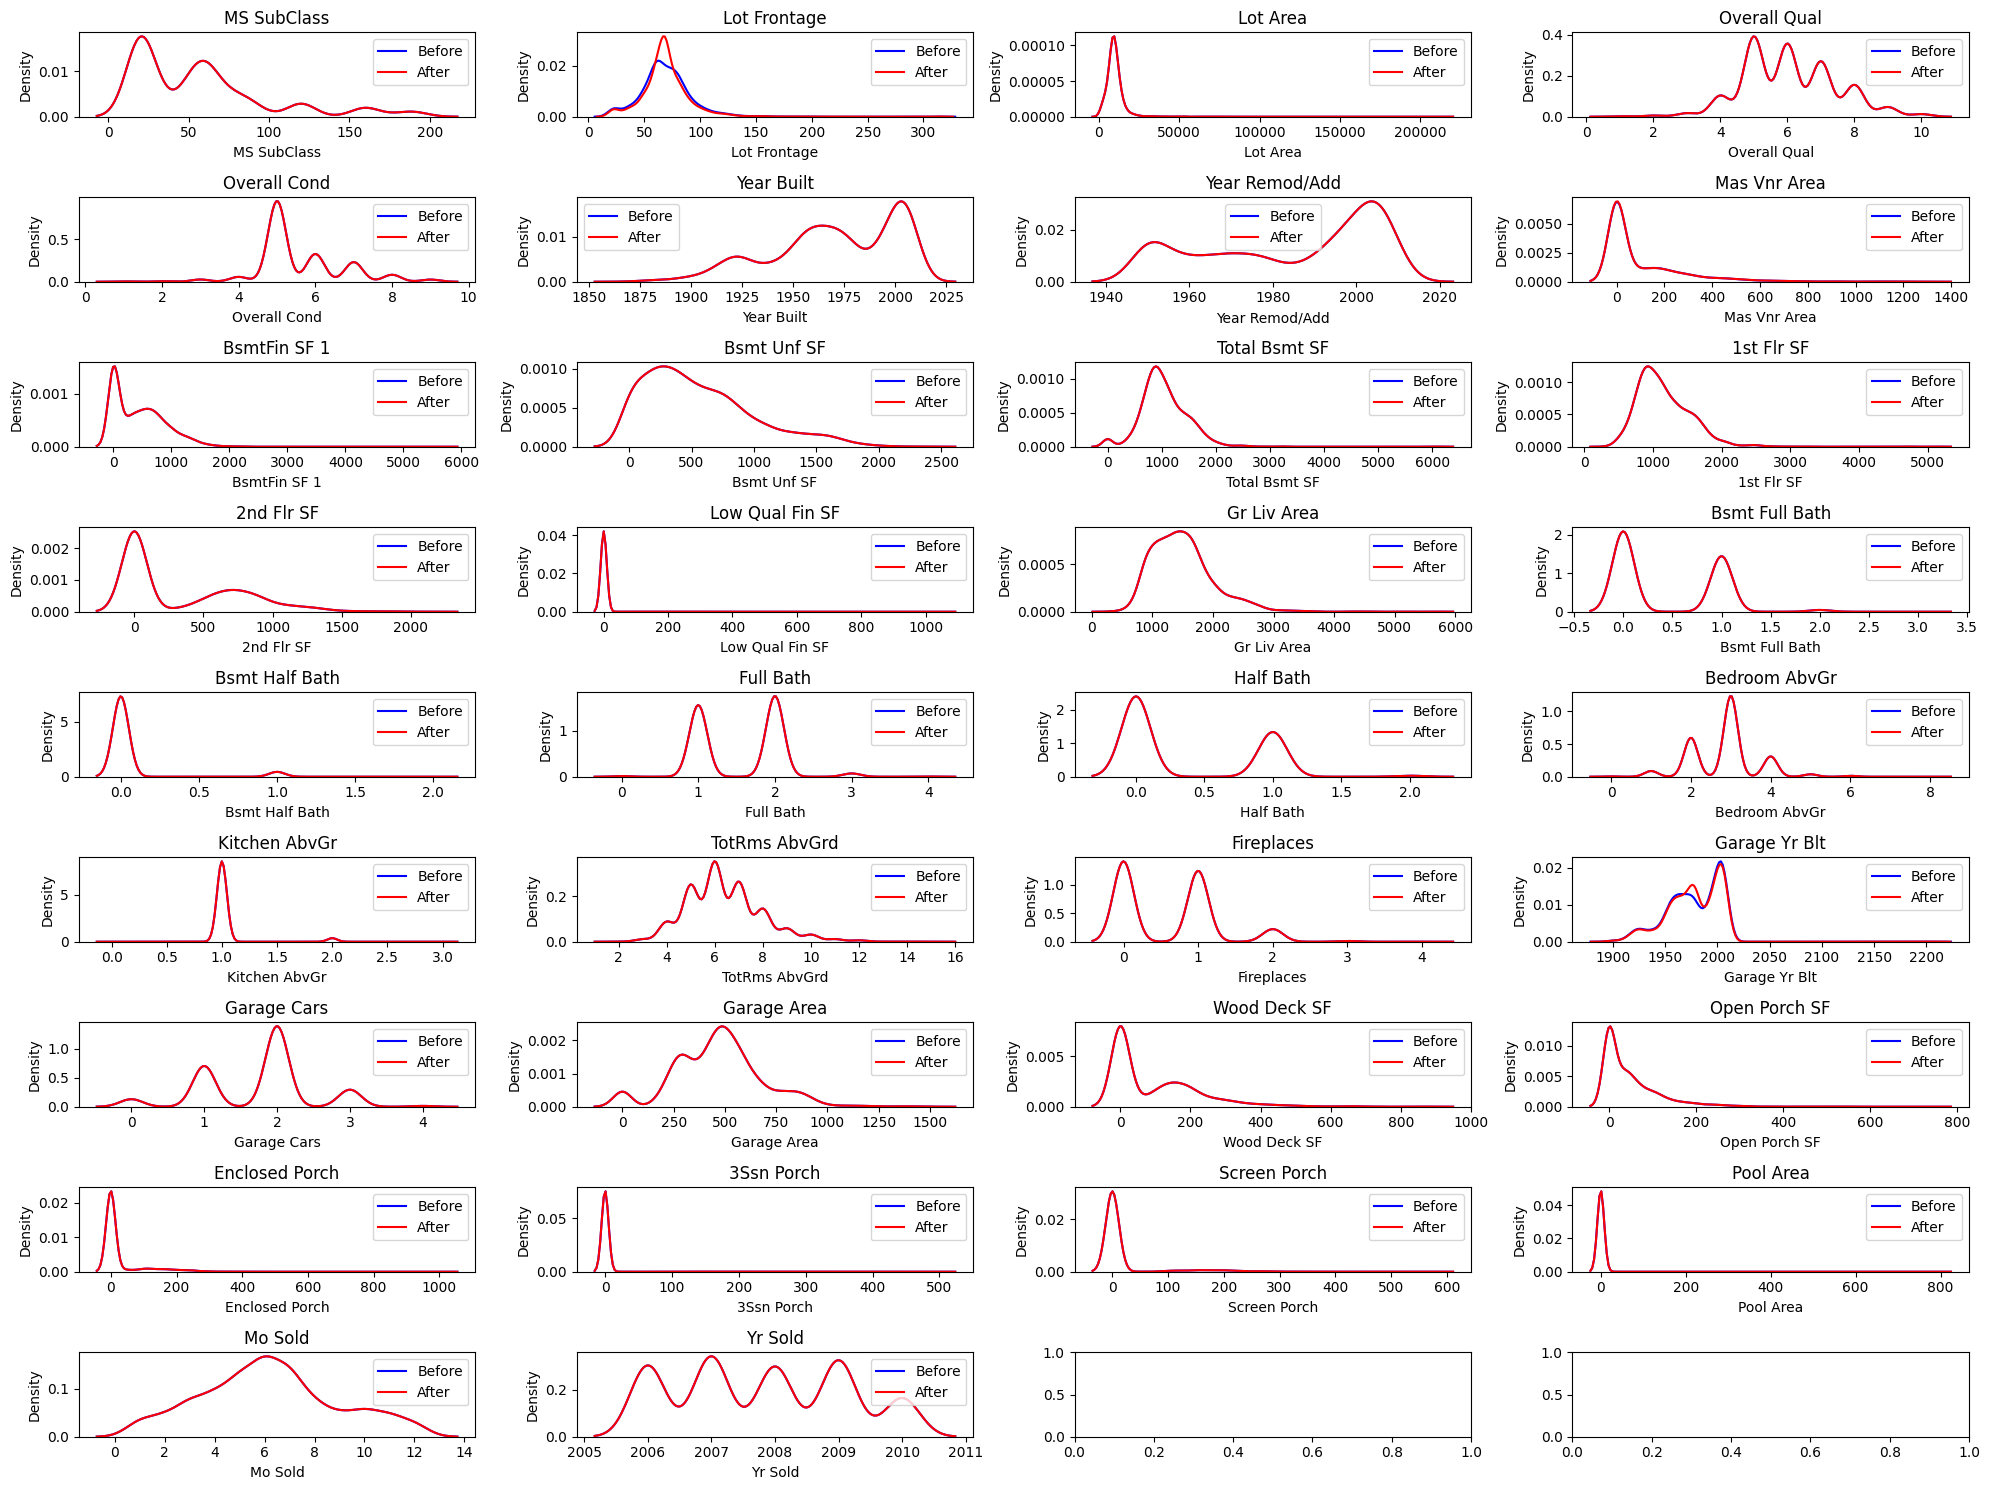

In [43]:
n_cols = 4
n_rows = math.ceil(len(num_cols)/n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.kdeplot(X_train[col], ax=axes[i], label='Before', color='blue')
    sns.kdeplot(X_train_num_median[col], ax=axes[i], label='After', color='red')
    axes[i].set_title(col)
    axes[i].legend()
plt.tight_layout()
plt.show()

# BEFORE & AFTER APPLY MODE ON CATEGORICAL COLUMNS

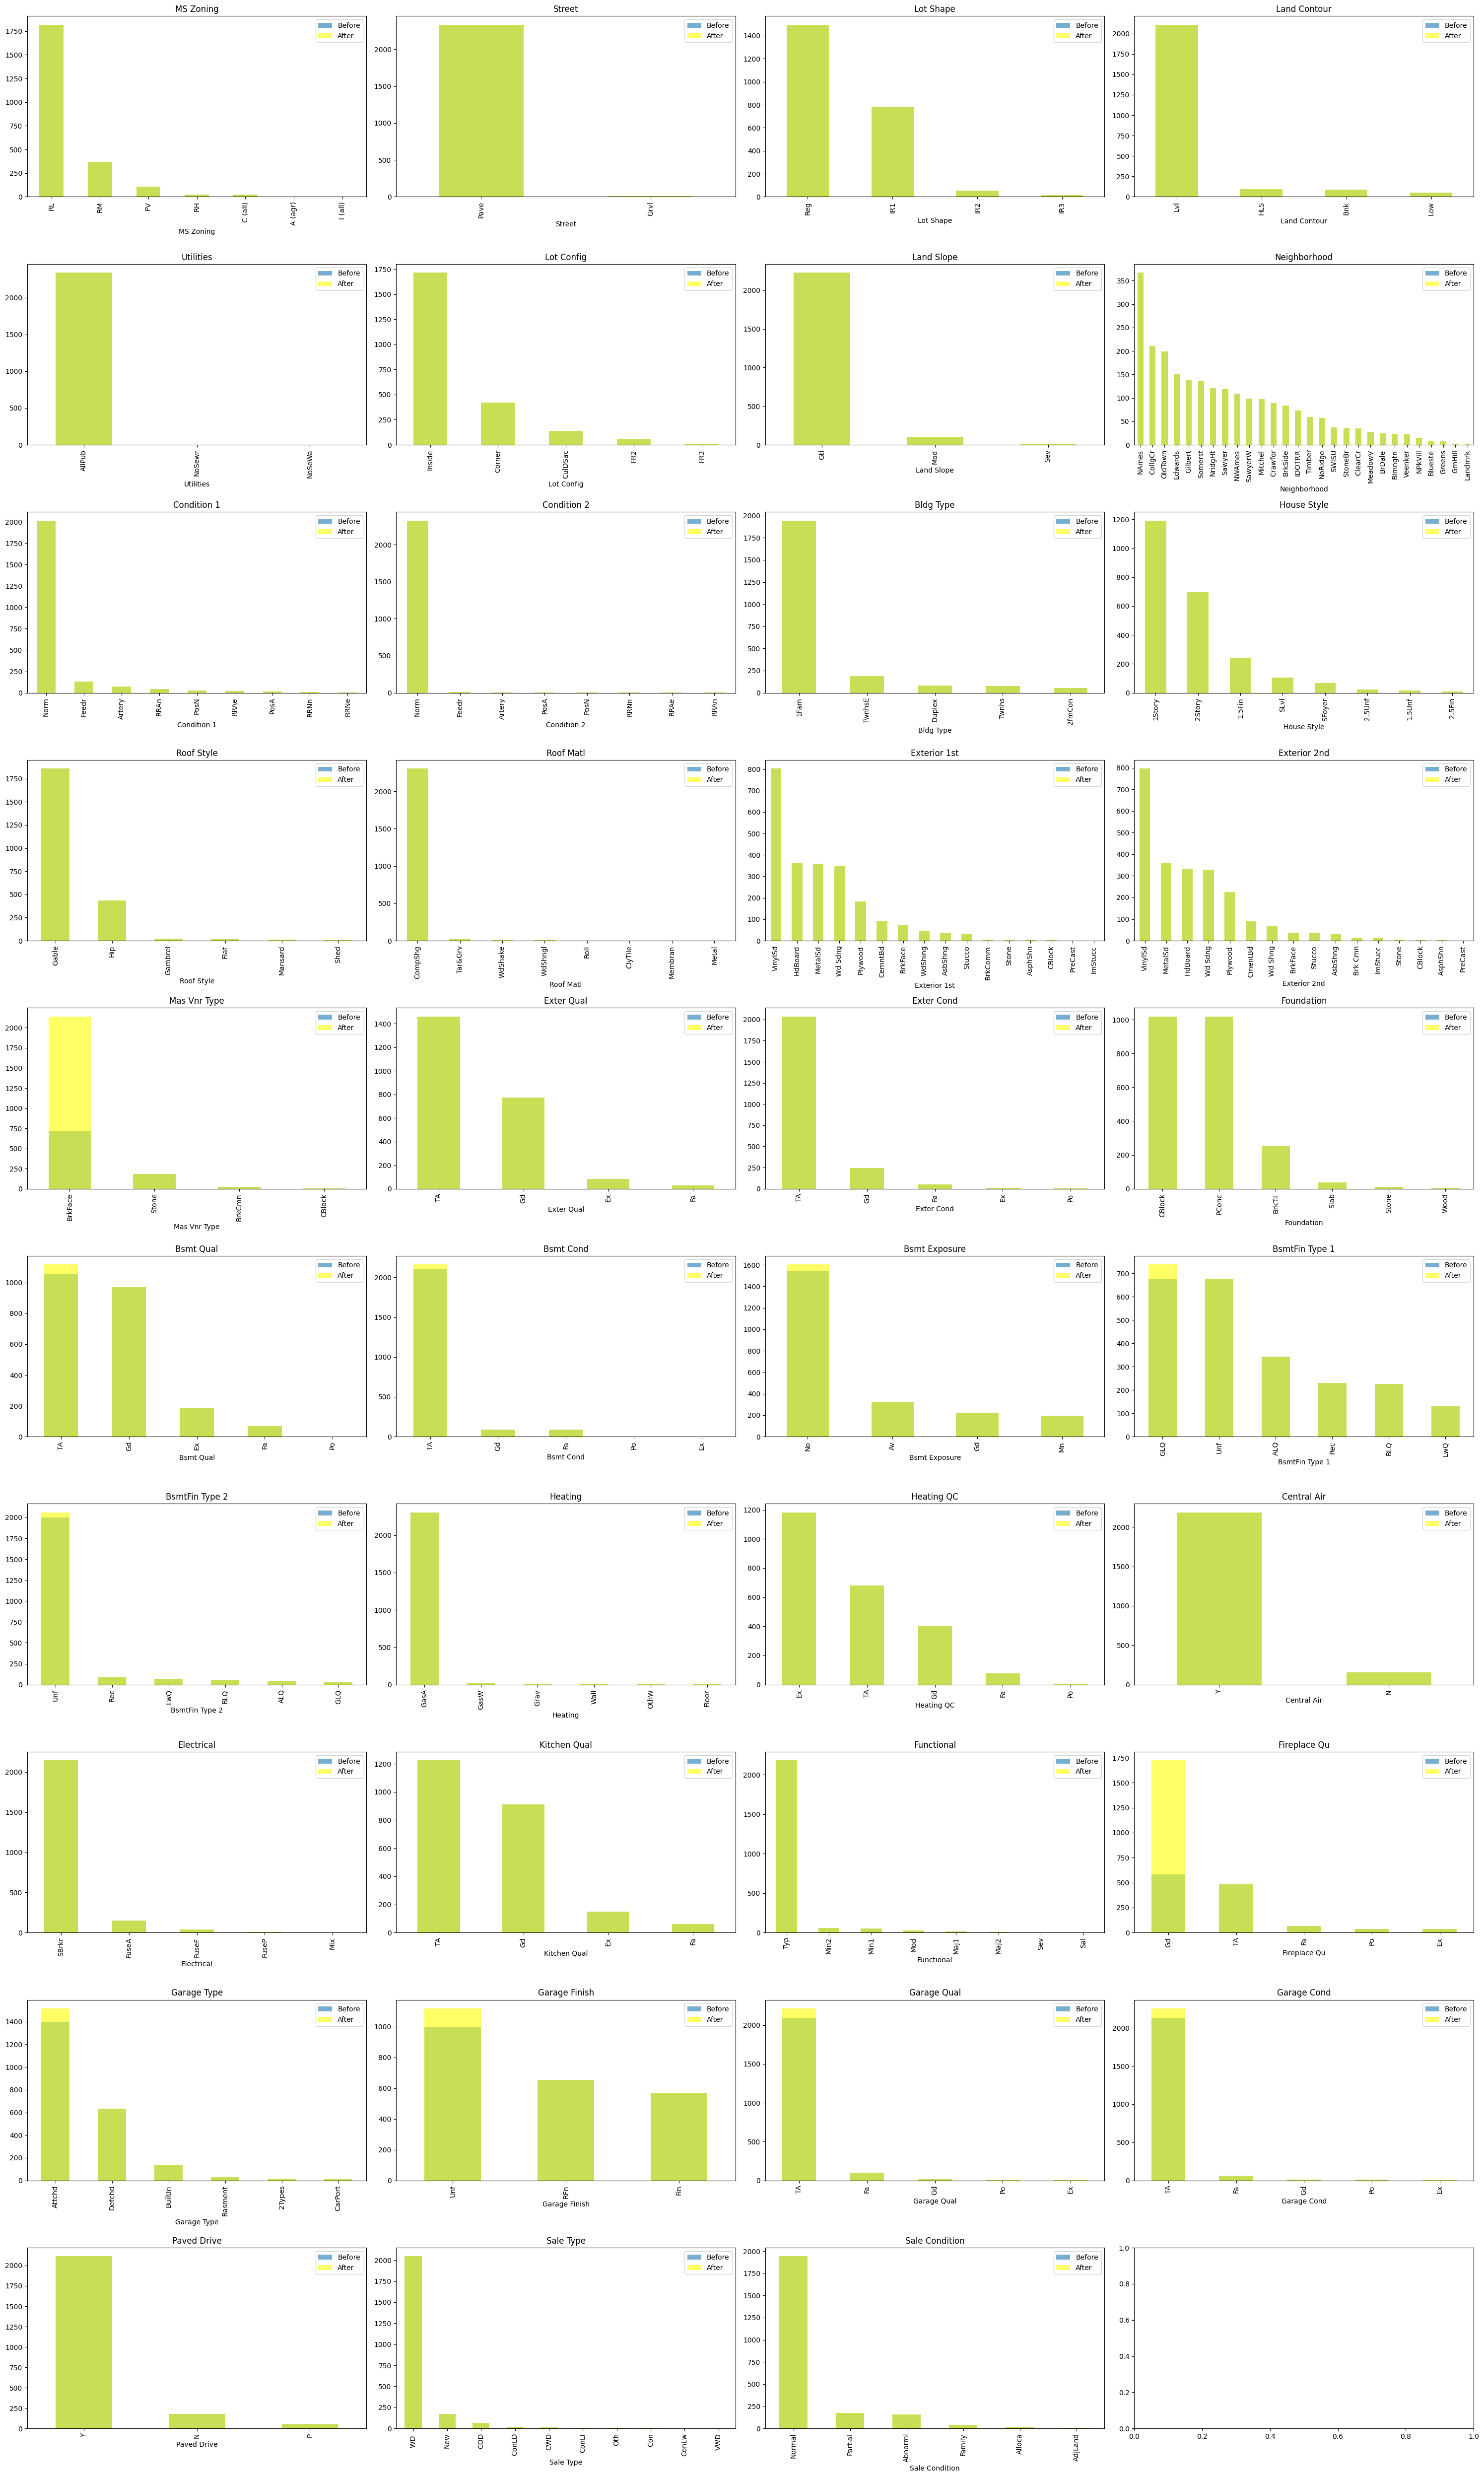

In [50]:
n_cols=4
n_rows=math.ceil(len(cat_cols)/n_cols)
fig, axes=plt.subplots(n_rows, n_cols, figsize=(30,50))
axes=axes.flatten()
for i, col in enumerate(cat_cols):
    X_train[col].value_counts().plot(kind='bar', ax=axes[i], alpha=0.6, label='Before')
    X_train_cat_mode[col].value_counts().plot(kind='bar', ax=axes[i], alpha=0.6, label='After',color="yellow")
    axes[i].set_title(col)
    axes[i].legend()
plt.tight_layout()
plt.show()

##  Data Preprocessing Summary (Ames Housing)

| Aspect | Column / Item | Type | Observation | Action | Reason |
|--------|----------------|------|-------------|--------|--------|
| Dataset | Ames Housing | — | 2930 rows, 82 columns | Used | Real-world regression data |
| Target | SalePrice | Numerical | Continuous | Kept | Prediction label |
| ID | Order, PID | Numerical | Identifiers | Dropped | No predictive value |
| Missing | Alley, Pool QC, Fence, Misc Feature | Categorical | 80–99% missing | Dropped | Too sparse |
| Missing | Lot Frontage, Mas Vnr Area | Numerical | Some missing | Median | Skewed data |
| Feature | MS SubClass | Numerical | \|corr\| ≈ 0.08 | Kept | Useful feature |
| Split | Train–Test | — | 80/20 | No stratify | Regression task |
| Verify | All features | — | After imputation | No nulls | Data cleaned |
